# lab01 · 值迭代 / Value Iteration on a stochastic 4×4 gridworld
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChatGPU/Autonomous-Driving-Learning-Atlas/blob/main/labs/lab01_zhao_value_iteration_gridworld.ipynb)

**配套节点**：[赵世钰课程](../docs/data/cards/course_zhao_shiyu_rl.md) ·
[`concept:value_iteration`](../concepts.md#值迭代--策略迭代)

**What this proves**：Bellman 算子是 $\gamma$-contraction，值迭代收敛到 $V^\star$；
$\gamma$ 越大收敛越慢；调高滑动概率后 $V^\star$ 的形状会被"模糊化"。


In [1]:
import numpy as np, matplotlib.pyplot as plt
np.random.seed(0)

# 4x4 grid: agent starts anywhere; goal at (3,3) reward +1; trap (1,1) reward -1; step cost -0.04
H, W = 4, 4
GOAL, TRAP = (3,3), (1,1)
ACTIONS = [(-1,0),(1,0),(0,-1),(0,1)]   # up, down, left, right
ACT_NAMES = ["↑","↓","←","→"]

def neighbors(s):
    return [((min(H-1,max(0,s[0]+a[0])), min(W-1,max(0,s[1]+a[1]))), a) for a in ACTIONS]

def step_reward(s):
    if s == GOAL: return 1.0
    if s == TRAP: return -1.0
    return -0.04

def value_iter(gamma=0.95, slip=0.1, n_iter=200, eps=1e-8):
    V = np.zeros((H,W))
    history = []
    for it in range(n_iter):
        V_new = np.zeros_like(V)
        for i in range(H):
            for j in range(W):
                s = (i,j)
                if s in (GOAL, TRAP):
                    V_new[i,j] = step_reward(s); continue
                vals = []
                for a_idx,(ns_intended,_) in enumerate(neighbors(s)):
                    # slip: with prob `slip`, move to a random other neighbor
                    others = [neighbors(s)[k][0] for k in range(4) if k!=a_idx]
                    expected = (1-slip)*V[ns_intended] + slip*np.mean([V[o] for o in others])
                    vals.append(step_reward(ns_intended) + gamma*expected)
                V_new[i,j] = max(vals)
        delta = np.max(np.abs(V_new - V)); V = V_new; history.append(V.copy())
        if delta < eps: break
    # extract greedy policy
    P = np.zeros((H,W), dtype=int)
    for i in range(H):
        for j in range(W):
            s=(i,j)
            if s in (GOAL,TRAP): P[i,j]=-1; continue
            vals=[]
            for a_idx,(ns_intended,_) in enumerate(neighbors(s)):
                others=[neighbors(s)[k][0] for k in range(4) if k!=a_idx]
                expected=(1-slip)*V[ns_intended]+slip*np.mean([V[o] for o in others])
                vals.append(step_reward(ns_intended)+gamma*expected)
            P[i,j]=int(np.argmax(vals))
    return V,P,history

V, pi, hist = value_iter(gamma=0.95, slip=0.1)
print("converged in", len(hist), "iterations")
print("V*:\n", np.round(V, 3))
print("pi (greedy):"); print("\n".join("  ".join("·" if x<0 else ACT_NAMES[x] for x in row) for row in pi))


converged in 27 iterations
V*:
 [[ 1.239  1.354  1.571  1.715]
 [ 1.354 -1.     1.637  1.868]
 [ 1.571  1.637  1.871  2.038]
 [ 1.715  1.868  2.038  1.   ]]
pi (greedy):
↓  →  →  ↓
↓  ·  ↓  ↓
↓  →  ↓  ↓
→  →  →  ·


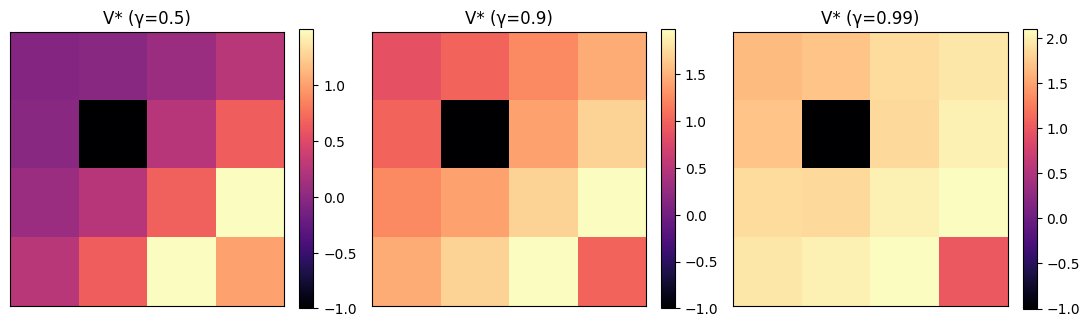

saved /tmp/lab01_V.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, g in zip(axes, [0.5, 0.9, 0.99]):
    Vg,_,_ = value_iter(gamma=g, slip=0.1, n_iter=400)
    im = ax.imshow(Vg, cmap="magma")
    ax.set_title(f"V* (γ={g})"); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig("/tmp/lab01_V.png", dpi=110); plt.show()
print("saved /tmp/lab01_V.png")


### 三个 stretch goals
1. 把 `slip` 从 0.1 调到 0.4，观察 $V^\star$ 与 π 的"模糊化"；
2. 把奖励地图改成两个 goal、一个 trap，重画策略箭头；
3. 加入 *策略迭代*（policy evaluation + improvement）并比较收敛步数。
